/home/gcilleru/miniconda3/envs/diffusion-pipe/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/gcilleru/miniconda3/envs/diffusion-pipe/lib/python3.12/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/gcilleru/miniconda3/envs/diffusion-pipe/lib/python3.12/site-packages/torch/cuda/__init__.py:991: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  r = torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


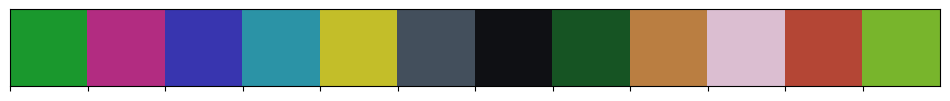

In [1]:

import pandas as pd
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams.update(mpl.rcParamsDefault)
# Update font settings for a more elegant look
plt.rcParams.update({
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb}"
})

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from utils.model_of_language import *
from utils.data import *
from utils.plots import *

quantifiers = ["gen", "all", "most", "many", "some", "few", "no", "often", "generally", "typically", "usually", "normally"]

# pd.Categorical(quant_mi["intervention"], categories=["all", "most", "many", "some", "few", "no", "often", "generally", "typically", "usually", "normally"], ordered=True)


In [31]:
def mean(l):
    return sum(l)/len(l)


def get_lowest_and_values(data, quantifiers):
    lowest_df = []
    values_df = []

    for d in tqdm(data):
        first_token_after_root_from_right = d['first_token_after_root_from_right']
        ds = []
        for q in quantifiers:
            if q == "gen":
                surprisal = d['target_measures']['surprisal']
                entropy = d['target_measures']['entropy']
                kl_div = d['target_measures']['kl_div']
            else:
                dq = [d['interventions'][i] for i in range(len(d['interventions'])) if d['interventions'][i]['text'].lower() == q.lower()][0]
                surprisal = dq['measures']['surprisal']
                entropy = dq['measures']['entropy']
                kl_div = dq['measures']['kl_div']
            
            for v in [surprisal, entropy, kl_div]:
                v = v[-first_token_after_root_from_right:]   
            
            
            ds.append({
                "quantifier": q,
                "surprisal": mean(surprisal),
                "entropy": mean(entropy),
                "kl_div": max(kl_div),
            })
        entropy_of_original_quantifier = [s["entropy"] for s in ds if s["quantifier"].lower() == d['original_quantifier'].lower()][0]
        for qdata in ds:
            qdata['entropy_diff'] = qdata['entropy'] - entropy_of_original_quantifier
        
        lowest_df.append({
                "id": d['id'],
                "original_quantifier": d['original_quantifier'],
                "lowest_surprisal": min(ds, key=lambda x: x['surprisal'])['quantifier'],
                "lowest_entropy": min(ds, key=lambda x: x['entropy'])['quantifier'],
                "lowest_kl_div": sorted(ds, key=lambda x: x['kl_div'])[1]['quantifier'],
            })
        
        
        for qdata in ds:
            values_df.append({
                "id": d['id'],
                "original_quantifier": d['original_quantifier'],
                "quantifier": qdata['quantifier'].lower(),
                "surprisal": qdata['surprisal'],
                "entropy": qdata['entropy'],
                "entropy_diff": qdata['entropy_diff'],
                "kl_div": qdata['kl_div'],
            })
            
    return pd.DataFrame(lowest_df), pd.DataFrame(values_df)
    

In [2]:
model_nickname="Qwen3Base"
model_nickname="Llama3.1" 

model_nickname="Qwen3-Instruct"


model_nickname="Mistral7B"
model_nickname="Llama3.1" 
model_nickname="Mistral8x22B"
model_nickname="Mistral7B"

In [116]:
context_data = {}

for n_context_sentences in tqdm(
    [3]

):
    data = load_jsonl_data(f"data/outputs/{model_nickname}/{n_context_sentences}s.jsonl")
    print(f"{n_context_sentences} context sentences: {len(data)}")
    df_lowest, df_values = get_lowest_and_values(data, quantifiers)
    context_data[n_context_sentences] = {
        "lowest": df_lowest,
        "values": df_values
    }


  0%|          | 0/1 [00:00<?, ?it/s]

3 context sentences: 679237


100%|██████████| 1/1 [04:24<00:00, 264.03s/it]


In [ ]:
df_values_by_context = pd.DataFrame()
df_lowest_by_context = pd.DataFrame()
for n_context_sentences in tqdm(
    [0,1,2,3,4,5]
    # [3]
):
    df_lowest, df_values = context_data[n_context_sentences]["lowest"], context_data[n_context_sentences]["values"]
    df_lowest["context_sentences"] = n_context_sentences
    df_values["context_sentences"] = n_context_sentences
    df_values_by_context = pd.concat([df_values_by_context, df_values])
    df_lowest_by_context = pd.concat([df_lowest_by_context, df_lowest])

df_values_by_context.to_csv(f"data/outputs/{model_nickname}/df_values_by_context.csv", index=False)
df_lowest_by_context.to_csv(f"data/outputs/{model_nickname}/df_lowest_by_context.csv", index=False)

100%|██████████| 1/1 [00:00<00:00, 154.66it/s]


In [3]:
df_values_by_context = pd.read_csv(f"data/outputs/{model_nickname}/df_values_by_context.csv")
df_lowest_by_context = pd.read_csv(f"data/outputs/{model_nickname}/df_lowest_by_context.csv")

In [21]:
# find quantifiers closer to the generic by the kldiv measure
target_quantifier = "normally"
df2 = df_values_by_context[(~(df_values_by_context['quantifier'].str.lower() == df_values_by_context['original_quantifier'].str.lower())) & (df_values_by_context['context_sentences'] == 3)]
    
# group by original_quantifier and id and aggregate by the minimum of kl_div
df_grouped = df2.groupby(['original_quantifier', 'id', 'context_sentences']).agg({'kl_div': 'min'}).reset_index()
df_grouped["smaller_than"] = df_grouped['kl_div'] < 0.5
df_grouped = df_grouped[df_grouped["original_quantifier"] == target_quantifier]
id_list = list(df_grouped[df_grouped["smaller_than"] == True]["id"])
print(len(id_list))

results = []
df2 = df_values_by_context[(df_values_by_context['quantifier'] != target_quantifier) & (df_values_by_context['context_sentences'] == 3) & (df_values_by_context['original_quantifier'] == target_quantifier)]
df2 = df2[df2["id"].isin(id_list)]
results = {}
for _, row in tqdm(df2.iterrows(), total=df2.shape[0]):
    ids = row["id"]
    if ids not in results:
        results[ids] = {
            "id": ids,
            "quantifier": row["quantifier"],
            "lowest_kl_div": row["kl_div"]
        }
    elif row["kl_div"] < results[ids]["lowest_kl_div"]:
        results[ids] = {
            "id": ids,
            "quantifier": row["quantifier"],
            "lowest_kl_div": row["kl_div"]
        }
results = list(results.values())
df = pd.DataFrame(results)
df.value_counts("quantifier")/df.shape[0]

1435


100%|██████████| 15785/15785 [00:00<00:00, 28088.12it/s]


quantifier
usually      0.589547
typically    0.227178
generally    0.170035
most         0.005575
gen          0.003484
often        0.003484
all          0.000697
Name: count, dtype: float64

In [4]:
# Calculate the kl divergences under different thresholds for each original quantifier
# for each quantifier, count the amount of samples in which there is a kl_div smaller than the threshold
all_df = pd.DataFrame()
for threshold in tqdm(
    # [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0]
    [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8,0.9,1,1.1, 1.2]
):
    df2 = df_values_by_context[(~(df_values_by_context['quantifier'].str.lower() == df_values_by_context['original_quantifier'].str.lower())) & (df_values_by_context['context_sentences'] == 3)]
    
    # group by original_quantifier and id and aggregate by the minimum of kl_div
    df_grouped = df2.groupby(['original_quantifier', 'id', 'context_sentences']).agg({'kl_div': 'min'}).reset_index()
    df_grouped["smaller_than"] = df_grouped['kl_div'] < threshold
    
    # count the number of samples for each quantifier
    df_kl_count = df_grouped[df_grouped["smaller_than"]].groupby(["original_quantifier", "context_sentences"]).size()
    
    # now make it percentage dividing by total counts
    df_kl_percentage = df_kl_count / df_grouped.groupby(["original_quantifier", "context_sentences"]).size() * 100
    
    # convert to df and reset index
    df_kl_percentage = df_kl_percentage.reset_index()
    df_kl_percentage.rename(columns={0: "percentage"}, inplace=True)
    df_kl_percentage["threshold"] = threshold
    
    all_df = pd.concat([all_df, df_kl_percentage], ignore_index=True)

# Reset index and ensure no duplicates
all_df = all_df.reset_index(drop=True)
# Remove any duplicate rows based on the key columns
all_df = all_df.drop_duplicates(subset=['original_quantifier', 'context_sentences', 'threshold'])

# make threshold categorical for proper ordering
# all_df["threshold"] = all_df["threshold"].astype(str)


  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:06<00:00,  1.85it/s]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


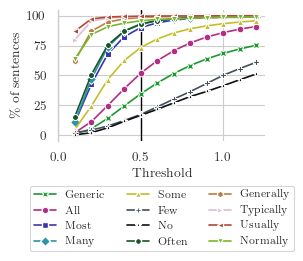

In [5]:
# Set style for a clean, scientific look
sns.set_style("whitegrid")
sns.set_context("paper")
all_df["threshold"] = all_df["threshold"].astype(float)
all_df["original_quantifier"] = pd.Categorical(all_df["original_quantifier"], categories=quantifiers, ordered=True)

# Create the lineplot showing how percentages evolve with thresholds
plt.figure(figsize=(3, 3))



# Define a list of markers, one for each quantifier
markers = ['X', 'o', 's', 'D', '^', 'P', '*', '8', 'h', '>', '<', 'v']

legend_handles = []
for color, marker in zip(custom_palette, markers):
    legend_handles.append(plt.Line2D([0], [0], color=color, marker=marker, linestyle='-', markeredgecolor="white"))

plt.axvline(x=0.5, color='black', linestyle='-', linewidth=1)

for i, (q, color) in enumerate(zip(quantifiers, custom_palette)):
    df_q = all_df[all_df["original_quantifier"] == q]
    marker = markers[i % len(markers)]
    sns.lineplot(
        data=df_q,
        x="threshold",
        y="percentage",
        color=color,
        marker=marker,
        label=q,
        legend=False,
        # linewidth=0.8
    )


# plt.title(r"\textrm{Percentage of samples with KL divergence below threshold}", pad=8)
plt.xlabel(r"\textrm{Threshold}")
plt.ylabel(r"\textrm{\% of sentences}")#, ha='right'
plt.xticks(np.arange(0, 1.2, 0.5))



# Add legend with LaTeX formatting
legend_labels = [r"\textrm{{{}}}".format(q.capitalize()) if q != "gen" else r"\textrm{{Generic}}" for q in quantifiers]
plt.legend(
    legend_handles,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.30),
    ncol=3,
    # title=r"\textrm{Quantifiers}",
    frameon=True,
    fontsize=8
)
# plt.legend(legend_handles, legend_labels,
#           bbox_to_anchor=(1.05, 1),
#           loc='upper left',
#           title=r"\textrm{Quantifiers}",
#           frameon=False)


# Remove top and right spines
sns.despine(bottom=True)

plt.tight_layout()
plt.savefig(f"data/figures/kl_div_thresholds_{model_nickname}.eps", format="eps", dpi=300, bbox_inches='tight')
plt.show()

In [4]:
data = load_jsonl_data(f"data/outputs/{model_nickname}/3s.jsonl")

In [5]:

df2 = df_values_by_context[(~(df_values_by_context['quantifier'].str.lower() == df_values_by_context['original_quantifier'].str.lower())) & (df_values_by_context['context_sentences'] == 3)]
min_kl = df2.groupby('id')['kl_div'].min().reset_index()
# Merge to get the corresponding quantifier(s)
df2 = pd.merge(min_kl, df2, on=['id', 'kl_div'], how='left')[['id', 'original_quantifier', 'quantifier', 'kl_div']]
id_to_target = {}
for d in data:
    id_to_target[d["id"]] = d["target"]

In [ ]:
#["gen", "all", "most", "many", "some", "few", "no", "often", "generally", "typically", "usually", "normally"]
df2["target"] = df2.apply(lambda x: id_to_target[x["id"]], axis=1)
# sort by kl_div
# df2 = df2.sort_values(by="kl_div")
for _,row in df2[(df2["original_quantifier"]=="gen")&(df2["kl_div"]<0.5)&(df2["quantifier"]=="many")][:100].iterrows():
    print(f" Original: {row['original_quantifier']}, Closest: {row['quantifier']}, KL Divergence: {row['kl_div']:.4f}, Target: {row['target']}, ID: {row['id']}")

In [ ]:
# Calculate the kkl divergences under 0.25 for each original quantifier
# for each quantifier, count the amount of samples in which there is a kl_div smaller than 0.25
n_kl_div_smaller_than_025 = {}
df2 = df_values_by_context[(~(df_values_by_context['quantifier'].str.lower() == df_values_by_context['original_quantifier'].str.lower()))]
# group by original_quantifier and id and aggregate by the minimum of kl_div
df_grouped = df2.groupby(['original_quantifier', 'id', 'context_sentences']).agg({'kl_div': 'min'}).reset_index()
df_grouped["smaller_than"] = df_grouped['kl_div'] < 0.25
# count the number of samples for each quantifier
df_kl_count = df_grouped[df_grouped["smaller_than"]].groupby(["original_quantifier", "context_sentences"]).size()
# now make it percentage dividing by total counts
df_kl_percentage = df_kl_count / df_grouped.groupby(["original_quantifier", "context_sentences"]).size() * 100
# convert to df and reset index
df_kl_percentage = df_kl_percentage.reset_index()
df_kl_percentage.rename(columns={0: "percentage"}, inplace=True)

# plot the percentage of samples for each quantifier and context sentences
sns.lineplot(data=df_kl_percentage, x="context_sentences", y="percentage", hue="original_quantifier", palette="tab10", marker="o")
plt.show()


<>:42: SyntaxWarning: invalid escape sequence '\%'
<>:42: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_424179/2370608123.py:42: SyntaxWarning: invalid escape sequence '\%'
  axes[idx].set_ylabel("\%", ha='right')
/tmp/ipykernel_424179/2370608123.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["counts"] = df["counts"] / df.groupby("context_sentences")["counts"].transform("sum")
/tmp/ipykernel_424179/2370608123.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["counts"] = df["count

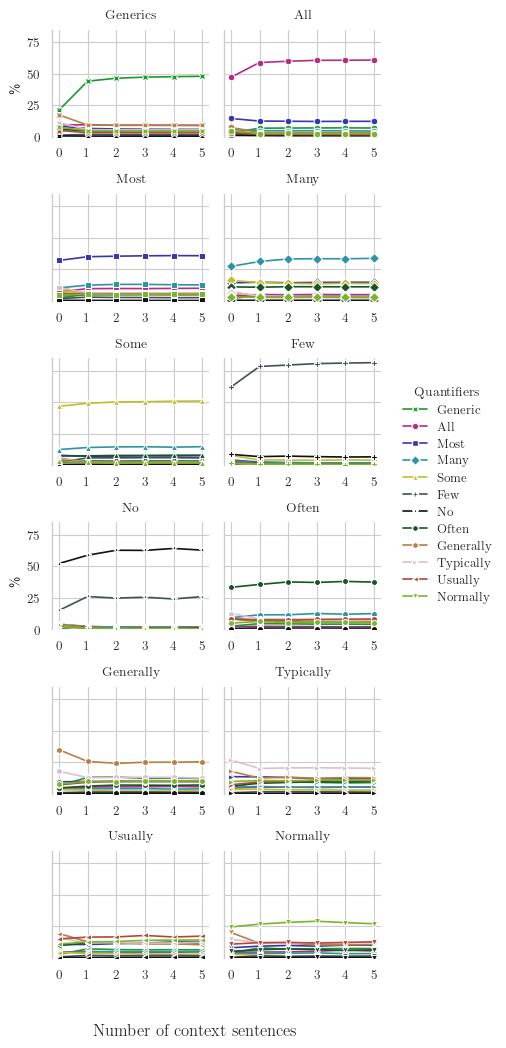

In [17]:
# Set style for a clean, scientific look
sns.set_style("whitegrid")
sns.set_context("paper")


fig, axes = plt.subplots(6, 2, figsize=(4, 10))
axes = axes.ravel()
# Define a list of markers, one for each quantifier
markers = ['X', 'o', 's', 'D', '^', 'P', '*', '8', 'h', '>', '<', 'v']

legend_handles = []
for color, marker in zip(custom_palette, markers):
    legend_handles.append(plt.Line2D([0], [0], color=color, marker=marker, linestyle='-', markeredgecolor="white"))


lowest = "lowest_surprisal"
df_grouped = df_lowest_by_context.groupby(["original_quantifier", "context_sentences", lowest]).agg({"id": "count"}).reset_index()
df_grouped.rename(columns={"id": "counts"}, inplace=True)
df_grouped["original_quantifier"] = pd.Categorical(df_grouped["original_quantifier"], categories=quantifiers, ordered=True)
df_grouped["lowest_surprisal"] = pd.Categorical(df_grouped["lowest_surprisal"], categories=quantifiers, ordered=True)


for idx, quantifier in enumerate(quantifiers):
    df = df_grouped[df_grouped["original_quantifier"] == quantifier]
    df["counts"] = df["counts"] / df.groupby("context_sentences")["counts"].transform("sum")
    df["counts"] = df["counts"] * 100
    
    sns.lineplot(
        data=df,
        x="context_sentences",
        y="counts",
        hue=lowest,
        ax=axes[idx],
        palette=custom_palette,
        marker=markers[idx % len(markers)],
        legend=False
    )
    
    # Customize appearance
    axes[idx].set_title(r"\textrm{{{}}}".format(quantifier.capitalize()) if quantifier != "gen" else r"\textrm{{Generics}}", pad=8)
    if idx % 6 == 0:
        axes[idx].set_ylabel("\%", ha='right')
    else:
        axes[idx].set_ylabel("")
        axes[idx].set_yticklabels([])
    axes[idx].set_ylim(0, 85)
    # axes[idx].set_yticks(np.arange(0, 1.1, 0.2))
    axes[idx].set_xlabel("")
    axes[idx].set_xticks([0,1,2,3,4,5])
    
    # Remove top and right spines
    sns.despine(bottom=True)

# Add a single legend to the right of the figure
legend_labels = [r"\textrm{{{}}}".format(q.capitalize()) if q != "gen" else r"\textrm{{Generic}}" for q in quantifiers]
fig.legend(legend_handles, legend_labels, 
          bbox_to_anchor=(0.99, 0.5),
          loc='center left',
          title=r"\textrm{{Quantifiers}}",
          frameon=False)
# plt.legend(
#     legend_handles,
#     legend_labels,
#     loc='upper center',
#     bbox_to_anchor=(0.5, -0.30),
#     ncol=3,
#     # title=r"\textrm{Quantifiers}",
#     frameon=True,
#     fontsize=8
# )

# write in the center of the plot "Number of context sentences"
fig.text(0.5, -0.04, r"\textrm{{Number of context sentences}}", ha='center', fontsize=12)
# fig.text(0.04

plt.tight_layout()
plt.savefig("data/figures/surprisal_evolution.eps", format="eps", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Calculate the kkl divergences under 0.25 for each original quantifier
# for each quantifier, count the amount of samples in which there is a kl_div smaller than 0.25
n_kl_div_smaller_than_025 = {}
df2 = df_values[~(df_values['quantifier'].str.lower() == df_values['original_quantifier'].str.lower())]
# group by original_quantifier and id and aggregate by the minimum of kl_div
df_grouped = df2.groupby(['original_quantifier', 'id']).agg({'kl_div': 'min'}).reset_index()
df_grouped["smaller_than"] = df_grouped['kl_div'] < 0.25
# count the number of samples for each quantifier
df_kl_count = df_grouped[df_grouped["smaller_than"]].groupby("original_quantifier").size()
# now make it percentage dividing by total counts
df_kl_percentage = df_kl_count / df_grouped.groupby("original_quantifier").size() * 100
df_kl_percentage

<>:56: SyntaxWarning: invalid escape sequence '\%'
<>:56: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_3522950/3545186066.py:56: SyntaxWarning: invalid escape sequence '\%'
  axes[idx].set_ylabel("\%", ha='right')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


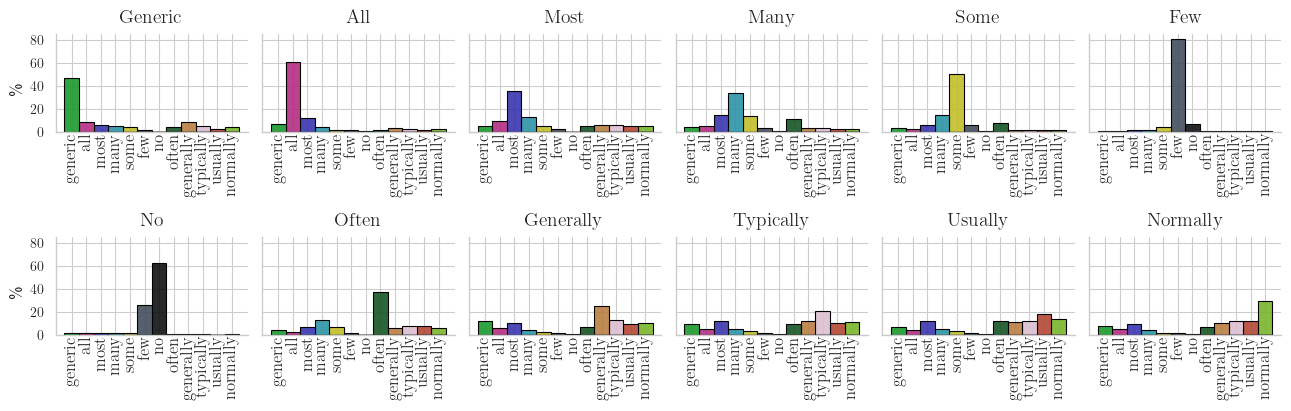

In [20]:
# Set style for a clean, scientific look

import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
sns.set_style("whitegrid")
sns.set_context("paper")
# Update font settings for a more elegant look
plt.rcParams.update({
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 10,
    "text.usetex": True,
    # "font.family": "serif",
    # "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb}"
})

fig, axes = plt.subplots(2, 6, figsize=(13, 4.2))
axes = axes.ravel()

df = df_lowest_by_context[df_lowest_by_context["context_sentences"] == 3]
df["lowest_surprisal"] = pd.Categorical(df["lowest_surprisal"], categories=quantifiers, ordered=True)
df["original_quantifier"] = pd.Categorical(df["original_quantifier"], categories=quantifiers, ordered=True)

# Sample 1000 samples per quantifier (original_quantifier) from df
# df = df.groupby("original_quantifier", group_keys=False).apply(lambda x: x.sample(n=min(1000, len(x)), random_state=42)).reset_index(drop=True)

# Create a proxy artist for the legend
# legend_handles = []
# for q, color in zip(quantifiers, custom_palette):
#     legend_handles.append(plt.Rectangle((0,0), 1, 1, fc=color, alpha=0.8, ec='black'))

for idx, quantifier in enumerate(quantifiers):
    df_plot = df[df["original_quantifier"] == quantifier]
    
    # Create subplot
    sns.histplot(
        data=df_plot,
        x="lowest_surprisal",
        ax=axes[idx],
        stat="percent",
        color='lightgray',
        palette=custom_palette,
        hue="lowest_surprisal",
        legend=False,
        alpha=0.9,
        edgecolor="black"
    )
    
    # Customize appearance
    # axes[idx].set_title(r"\textrm{{{}}} \small{{($N={}$)}}".format(quantifier.capitalize(), len(df_plot['id'].unique())) if quantifier != "gen" else r"\textrm{{Generics}} \small{{($N={}$)}}".format(len(df_plot['id'].unique())) , pad=8)
    axes[idx].set_title(r"\textrm{{{}}}".format(quantifier.capitalize()) if quantifier != "gen" else r"\textrm{{Generic}}", pad=8)
    axes[idx].set_xlabel("")
    if idx % 6 == 0:
        axes[idx].set_ylabel("\%", ha='right')
    else:
        axes[idx].set_ylabel("")
        axes[idx].set_yticklabels([])
    axes[idx].tick_params(axis='x', rotation=90, pad=-3)
    axes[idx].set_xticks([0,1,2,3,4,5,6,7,8,9,10,11], [r'\textrm{{{}}}'.format(q) if q!="gen" else r'\textrm{generic}' for q in quantifiers])
    axes[idx].set_ylim(0, 85)
    axes[idx].set_yticks(np.arange(0, 81, 20))
    
    # Remove top and right spines
    sns.despine()

plt.tight_layout()

# Add a single legend to the right of the figure
# legend_labels = [r"\textrm{{{}}}".format(q.capitalize()) if q != "gen" else r"\textrm{{Generic}}" for q in quantifiers]
# fig.legend(legend_handles, legend_labels, 
#           bbox_to_anchor=(1.02, 0.5),
#           loc='center left',
#           title="",
#           frameon=False)

# Adjust layout to make room for legend
plt.subplots_adjust(right=0.92)

plt.tight_layout()
# Save as EPS without LaTeX
# plt.rcParams["text.usetex"] = False
plt.savefig("data/figures/surprisal_histograms_c5.eps", format="eps", dpi=300, bbox_inches='tight')
# Re-enable LaTeX for display
# plt.rcParams["text.usetex"] = True
plt.show()

/tmp/ipykernel_1599206/761812800.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels([r'\textrm{{{}}}'.format(q) for q in quantifiers])
/tmp/ipykernel_1599206/761812800.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels([r'\textrm{{{}}}'.format(q) for q in quantifiers])
/tmp/ipykernel_1599206/761812800.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels([r'\textrm{{{}}}'.format(q) for q in quantifiers])
/tmp/ipykernel_1599206/761812800.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels([r'\textrm{{{}}}'.format(q) for q in quantifiers])
/tmp/ipykern

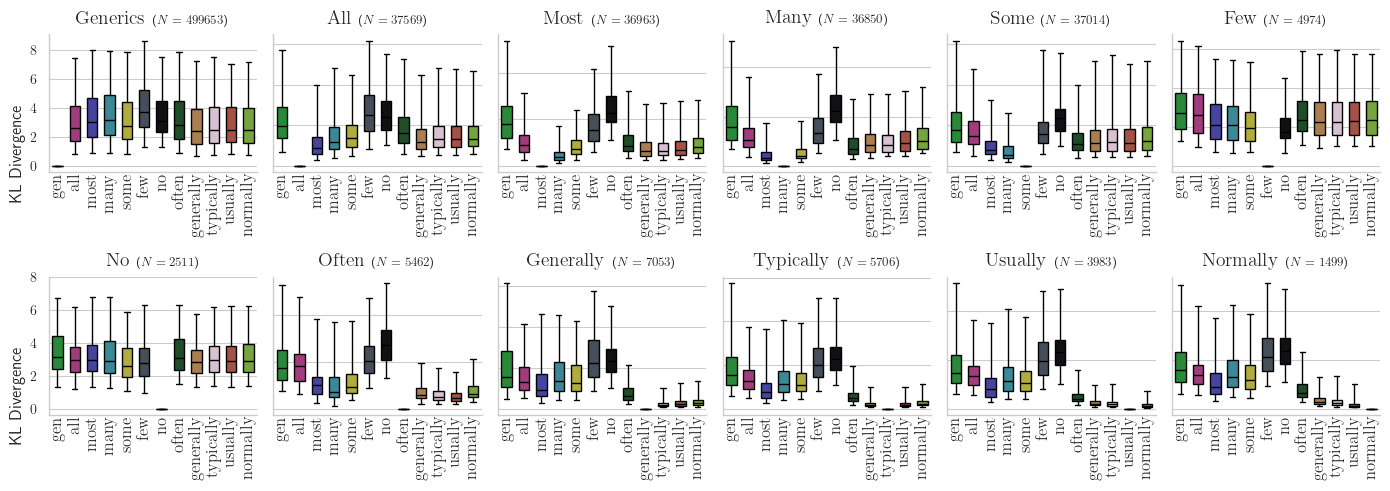

In [12]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
axes = axes.ravel()

df_kl = df_values_by_context[df_values_by_context["context_sentences"] == 0]

for idx, quantifier in enumerate(quantifiers):
    df_plot = df_kl[df_kl["original_quantifier"] == quantifier]
    
    # Create subplot
    sns.boxplot(
        data=df_plot,
        x="quantifier",
        y="kl_div",
        order=quantifiers,
        ax=axes[idx],
        showfliers=False,
        whis=[2.5, 97.5],
        width=0.6,
        color='lightgray',
        # fliersize=2,
        hue="quantifier",
        palette=custom_palette,
        
        medianprops={"color": "black"},
        boxprops={"edgecolor": "black"},
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
        
    )
    
    # Customize appearance
    axes[idx].set_title(r"\textrm{{{}}} \small{{($N={}$)}}".format(quantifier.capitalize(), len(df_plot['id'].unique())) if quantifier != "gen" else r"\textrm{{Generics}} \small{{($N={}$)}}".format(len(df_plot['id'].unique())) , pad=8)
    axes[idx].set_xlabel("")
    if idx % 6 == 0:
        axes[idx].set_ylabel("KL Divergence", ha='right')
        # yticks 0,2,4,8
        axes[idx].set_yticks([0,2,4,6,8])
    else:
        axes[idx].set_ylabel("")
        axes[idx].set_yticklabels([])
    axes[idx].tick_params(axis='x', rotation=90, pad=-3)
    axes[idx].set_xticklabels([r'\textrm{{{}}}'.format(q) for q in quantifiers])
    
    # Remove top and right spines
    sns.despine()

plt.tight_layout()
plt.savefig("data/figures/kl_divergence_boxplots_c5.eps", format="eps", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.special import kl_div
import seaborn as sns

def discrete_normal_pmf(x, mu, sigma, support_range):
    """
    Create a discrete normal PMF over a finite support.
    
    Args:
        x: array of discrete values
        mu: mean of the normal distribution
        sigma: standard deviation of the normal distribution
        support_range: range of the support (min, max)
    
    Returns:
        PMF values (normalized to sum to 1)
    """
    # Calculate continuous normal PDF
    pdf_values = norm.pdf(x, mu, sigma)
    
    # Normalize to create a valid PMF
    pmf_values = pdf_values / np.sum(pdf_values)
    
    return pmf_values

def uniform_pmf(x, support_range):
    """
    Create a uniform PMF over the support.
    
    Args:
        x: array of discrete values
        support_range: range of the support (min, max)
    
    Returns:
        PMF values (uniform)
    """
    n_points = len(x)
    return np.ones(n_points) / n_points

def kl_divergence(p, q):
    """
    Calculate KL divergence D_KL(P||Q) where P and Q are PMFs.
    
    Args:
        p: PMF of distribution P
        q: PMF of distribution Q
    
    Returns:
        KL divergence value
    """
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    p_safe = p + epsilon
    q_safe = q + epsilon
    
    # Normalize to ensure they sum to 1
    p_safe = p_safe / np.sum(p_safe)
    q_safe = q_safe / np.sum(q_safe)
    
    # Calculate KL divergence
    kl_div_value = np.sum(p_safe * np.log(p_safe / q_safe))
    
    return kl_div_value

def compare_distributions(mu=0, sigma=1, support_min=-5, support_max=5, n_points=100):
    """
    Compare discrete normal and uniform distributions.
    
    Args:
        mu: mean of normal distribution
        sigma: standard deviation of normal distribution
        support_min: minimum value of support
        support_max: maximum value of support
        n_points: number of discrete points
    
    Returns:
        kl_div_normal_to_uniform: KL divergence from normal to uniform
        kl_div_uniform_to_normal: KL divergence from uniform to normal
        x: support points
        normal_pmf: normal distribution PMF
        uniform_pmf: uniform distribution PMF
    """
    # Create discrete support
    x = np.linspace(support_min, support_max, n_points)
    
    # Calculate PMFs
    normal_pmf = discrete_normal_pmf(x, mu, sigma, (support_min, support_max))
    uniform_pmf_values = uniform_pmf(x, (support_min, support_max))
    
    # Calculate KL divergences
    kl_div_normal_to_uniform = kl_divergence(normal_pmf, uniform_pmf_values)
    kl_div_uniform_to_normal = kl_divergence(uniform_pmf_values, normal_pmf)
    
    return kl_div_normal_to_uniform, kl_div_uniform_to_normal, x, normal_pmf, uniform_pmf_values

def plot_distributions(x, normal_pmf, uniform_pmf, mu, sigma, support_min, support_max):
    """
    Plot both PMFs for comparison.
    
    Args:
        x: support points
        normal_pmf: normal distribution PMF
        uniform_pmf: uniform distribution PMF
        mu: mean of normal distribution
        sigma: standard deviation of normal distribution
        support_min: minimum value of support
        support_max: maximum value of support
    """
    plt.figure(figsize=(12, 8))
    
    # Plot PMFs
    plt.subplot(2, 1, 1)
    plt.plot(x, normal_pmf, 'b-', linewidth=2, label=f'Discrete Normal (μ={mu}, σ={sigma})')
    plt.plot(x, uniform_pmf, 'r-', linewidth=2, label='Uniform')
    plt.xlabel('x')
    plt.ylabel('PMF')
    plt.title('Probability Mass Functions Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot difference
    plt.subplot(2, 1, 2)
    difference = normal_pmf - uniform_pmf
    plt.plot(x, difference, 'g-', linewidth=2, label='Normal - Uniform')
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    plt.xlabel('x')
    plt.ylabel('PMF Difference')
    plt.title('Difference between Normal and Uniform PMFs')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def main():
    """
    Main function to run the comparison.
    """
    # Parameters
    mu = 0          # mean of normal distribution
    sigma = 1       # standard deviation of normal distribution
    support_min = -5  # minimum value of support
    support_max = 5   # maximum value of support
    n_points = 4    # number of discrete points
    
    print("Comparing Discrete Normal and Uniform Distributions")
    print("=" * 50)
    print(f"Normal distribution parameters: μ={mu}, σ={sigma}")
    print(f"Support range: [{support_min}, {support_max}]")
    print(f"Number of discrete points: {n_points}")
    print()
    
    # Calculate distributions and KL divergence
    kl_normal_to_uniform, kl_uniform_to_normal, x, normal_pmf, uniform_pmf = compare_distributions(
        mu, sigma, support_min, support_max, n_points
    )
    
    # Print results
    print("KL Divergence Results:")
    print(f"D_KL(Normal || Uniform) = {kl_normal_to_uniform:.6f}")
    print(f"D_KL(Uniform || Normal) = {kl_uniform_to_normal:.6f}")
    print()
    print("Note: KL divergence is not symmetric!")
    
    # Plot distributions
    plot_distributions(x, normal_pmf, uniform_pmf, mu, sigma, support_min, support_max)
    
    return kl_normal_to_uniform, kl_uniform_to_normal, x, normal_pmf, uniform_pmf


results = main()

# You can also access the results programmatically
kl_normal_to_uniform, kl_uniform_to_normal, x, normal_pmf, uniform_pmf = results


In [17]:
# find the df_lowest_by_context where in context=0 og_quantifeir is gen but lowest_surprisal is not gen, but in context=1 og_quantifier is gen and lowest_surprisal is gen
ids_gen_non_gen_0 = df_lowest_by_context[(df_lowest_by_context['context_sentences'] == 0) & (df_lowest_by_context['original_quantifier'] == 'gen') & (df_lowest_by_context['lowest_surprisal'] != 'gen')]["id"].unique()
ids_gen_gen_1 = df_lowest_by_context[(df_lowest_by_context['context_sentences'] == 1) & (df_lowest_by_context['original_quantifier'] == 'gen') & (df_lowest_by_context['lowest_surprisal'] == 'gen')]["id"].unique()

common_ids = set(ids_gen_non_gen_0).intersection(set(ids_gen_gen_1))



In [46]:
df = df_lowest_by_context[(df_lowest_by_context['context_sentences'] == 0) & (df_lowest_by_context["id"].isin(common_ids))]
# make an id: lowest_surprisal dictionary
id_lowest_surprisal = {}
for _, row in df.iterrows():
    id_lowest_surprisal[row["id"]] = row["lowest_surprisal"]


In [19]:
data = load_jsonl_data("data/5s5.jsonl")

In [48]:
gen_change = []
for d in tqdm(data):
    if d["id"] in common_ids:
        if "interventions" in d:
            d.pop('interventions')
        gen_change.append({
            "id": d["id"],
            "doc_id": d["doc_id"],
            "left": d["left_context"][-1],
            "target": d["target"],
            "confused_quantifier": id_lowest_surprisal[d["id"]]
        })

100%|██████████| 679237/679237 [00:01<00:00, 655901.03it/s]


In [51]:
gen_change[:10]

[{'id': '07fb1b26091e0b43d2790f6a5027b0d8a1dc5cee_6',
  'doc_id': '07fb1b26091e0b43d2790f6a5027b0d8a1dc5cee',
  'left': 'Pompousness leads to lavishness.',
  'target': "Families compete on the bride's jewellery, attires and feasts forgetting own financial conditions.",
  'confused_quantifier': 'generally'},
 {'id': 'c53d44c325f6762ebf7986800ebac26fb1ff3fa7_176',
  'doc_id': 'c53d44c325f6762ebf7986800ebac26fb1ff3fa7',
  'left': 'Detection strategies DLAD methods choose their detection strategies from three aspects: Input data.',
  'target': 'DLAD methods first need to decide what type of data to take as input, which depends on specific anomalies they tend to detect.',
  'confused_quantifier': 'most'},
 {'id': '2f331c19b08bfe432cb98cbf535560920435c47d_424',
  'doc_id': '2f331c19b08bfe432cb98cbf535560920435c47d',
  'left': 'Communication becomes more coherent and they are able to communicate their needs more effi\xad ciently, although this is egocentric and simple.',
  'target': 'Patients

In [52]:
gen_change_df = pd.DataFrame(gen_change)
gen_change_df.to_csv("data/gen_change_df.csv", index=False)

In [6]:
gen_data = pd.read_csv("data/gen_change_scored_for_generics.csv")

In [17]:
def has_quantifier(text):
    quantifiers_all =[
    # Quantifiers
    "all", "some", "each", "every", "no", "much", "more", "most",
    "less", "few", "several", "many", "enough", "little", "various",
    
    # Frequency adverbs
    "always", "usually", "often", "frequently", "sometimes",
    "occasionally", "seldom", "rarely", "never",
    
    # Degree adverbs
    "almost", "nearly", "hardly", "scarcely", "barely",
    "completely", "entirely", "totally", "absolutely", "partly",
    "largely", "mostly", "extremely", "exceptionally",
    "especially", "particularly"
]
    quantifiers_all=["gen", "all", "most", "many", "some", "few", "no", "often", "generally", "typically", "usually", "normally"]

    words = [w.strip() for w in text.lower().split(" ")]
    for word in words:
        if word in quantifiers_all:
            return True
    return False



gen_data["is_gen"] = gen_data["score"] > 0.8
gen_data["has_quantifier"] = gen_data["left"].apply(has_quantifier)


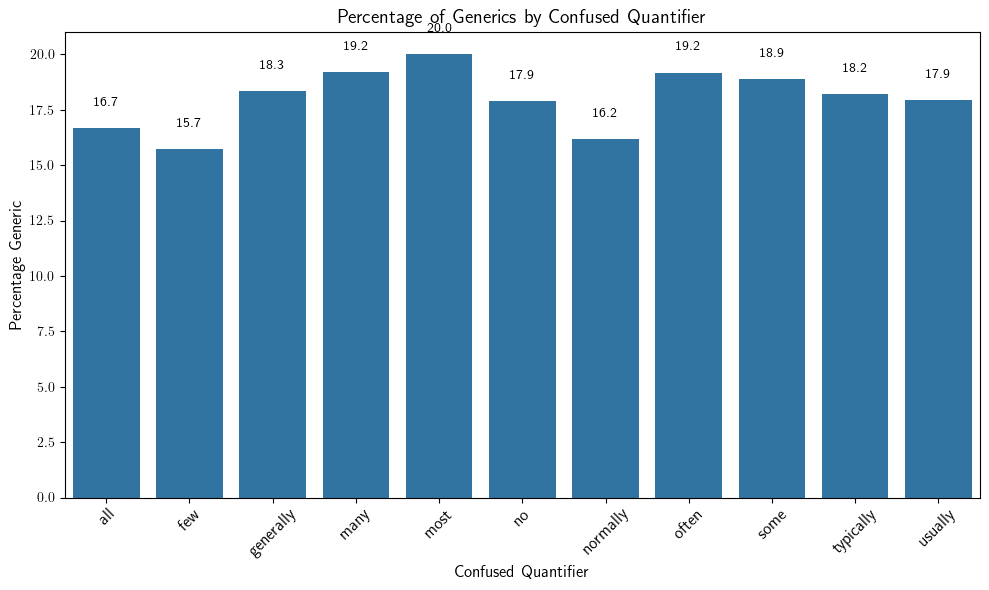

In [18]:


# plot % of x_gen per confused_quantifier
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate percentage of generics per confused quantifier
gen_percentages = (gen_data.groupby('confused_quantifier')['has_quantifier']
                  .mean() * 100).reset_index()

# Create bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=gen_percentages, x='confused_quantifier', y='has_quantifier')

# Customize plot
plt.title('Percentage of Generics by Confused Quantifier')
plt.xlabel('Confused Quantifier')
plt.ylabel('Percentage Generic')
plt.xticks(rotation=45)

# Add percentage labels on bars
for i, v in enumerate(gen_percentages['has_quantifier']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()


In [2]:
gen_change_df = pd.read_csv("data/gen_change_df.csv")

In [ ]:
quantifiers_all =[
    # Quantifiers
    "all", "some", "each", "every", "no", "much", "more", "most",
    "less", "few", "several", "many", "enough", "little", "various",
    
    # Frequency adverbs
    "always", "usually", "often", "frequently", "sometimes",
    "occasionally", "seldom", "rarely", "never",
    
    # Degree adverbs
    "almost", "nearly", "hardly", "scarcely", "barely",
    "completely", "entirely", "totally", "absolutely", "partly",
    "largely", "mostly", "extremely", "exceptionally",
    "especially", "particularly"
]

q_found = {q: 0 for q in quantifiers_all}

for _,row in tqdm(gen_change_df.iterrows()):
    words = [w.strip() for w in row["left"].lower().split(" ")]
    for word in words:
        if word in quantifiers_all:
            q_found[word] += 1
            break
            
            
q_found
    
    











137876it [00:05, 24016.86it/s]


{'all': 4226,
 'some': 3414,
 'each': 1959,
 'every': 971,
 'no': 2305,
 'much': 1665,
 'more': 5853,
 'most': 4388,
 'less': 1045,
 'few': 795,
 'several': 1044,
 'many': 3200,
 'enough': 462,
 'little': 630,
 'various': 903,
 'always': 758,
 'usually': 1307,
 'often': 1873,
 'frequently': 256,
 'sometimes': 479,
 'occasionally': 81,
 'seldom': 37,
 'rarely': 133,
 'never': 464,
 'almost': 556,
 'nearly': 248,
 'hardly': 45,
 'scarcely': 9,
 'barely': 16,
 'completely': 198,
 'entirely': 98,
 'totally': 83,
 'absolutely': 74,
 'partly': 53,
 'largely': 187,
 'mostly': 327,
 'extremely': 282,
 'exceptionally': 24,
 'especially': 683,
 'particularly': 463}

/tmp/ipykernel_2982950/2021500849.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())
/tmp/ipykernel_2982950/2021500849.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([r"\textrm{{{}}}".format(tick.get_text()) for tick in ax.get_xticklabels()], size=10)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


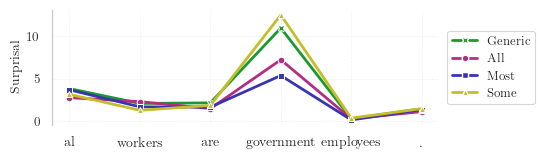

In [7]:
sentence=Sentence(id=None, context='', target='Postal workers are government employees.', original_quantifier=None, intervened_target='postal workers are government employees.', target_measures={'entropy': [4.51953125, 4.57421875, 4.359375, 5.55078125, 1.056640625, 2.521484375], 'surprisal': [3.841796875, 2.08984375, 2.158203125, 10.9921875, 0.274658203125, 1.458984375], 'kl_div': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, context_cached_hidden_states=None, measure_tokens=['al', 'workers', 'are', 'government', 'employees', '.'], interventions=[Intervention(text='All', measures={'entropy': [3.794921875, 4.12890625, 3.619140625, 5.2109375, 1.08984375, 2.375], 'surprisal': [2.771484375, 2.298828125, 1.48046875, 7.24609375, 0.2734375, 1.12890625], 'kl_div': [1.6806640625, 2.1640625, 0.4931640625, 1.541015625, 0.0513916015625, 0.2578125]}), Intervention(text='Most', measures={'entropy': [3.314453125, 4.234375, 4.31640625, 5.4375, 0.68994140625, 2.27734375], 'surprisal': [3.697265625, 1.689453125, 1.654296875, 5.3828125, 0.14404296875, 1.3720703125], 'kl_div': [1.470703125, 1.943359375, 0.91943359375, 2.111328125, 0.058990478515625, 0.09735107421875]}), Intervention(text='Some', measures={'entropy': [3.48828125, 4.07421875, 3.759765625, 5.80859375, 1.5009765625, 2.28125], 'surprisal': [3.16015625, 1.2802734375, 1.8564453125, 12.5390625, 0.35009765625, 1.4755859375], 'kl_div': [1.607421875, 1.650390625, 0.20654296875, 0.55712890625, 0.1187744140625, 0.361572265625]})], original_intervention_index=0, first_token_after_root_from_right=3)




def plot_sentence(sentence, save_path=None, measure_name="surprisal"):
    # plot the raw measure across the tokens
    sns.set_style("whitegrid")
    sns.set_context("paper")
    # Set the custom palette
    sns.set_palette(custom_palette)
    
    fig, ax = plt.subplots(figsize=(5, 1.5))
    sns.lineplot(
            y=sentence.target_measures[measure_name],
            x=sentence.measure_tokens, 
            marker='X', 
            linestyle='-', 
            linewidth=2, 
            label=f"GEN",
            color=custom_palette[0],  # Use custom colors
            ax=ax
        )
    ax.set_xticklabels(ax.get_xticklabels())
    ax.set_yticks([0,5,10])
    # add a horizontal line at the mean of the target measures
    for i, intervention in enumerate(sentence.interventions):
        sns.lineplot(
            y=intervention.measures[measure_name], 
            x=sentence.measure_tokens, 
            marker='o' if i == 0 else 's' if i == 1 else '^', 
            linestyle='-', 
            linewidth=2, 
            label=f"{intervention.text}",
            color=custom_palette[1] if i == 0 else custom_palette[2] if i == 1 else custom_palette[4],  # Use custom colors
            ax=ax
        )
    ax.set_xticklabels([r"\textrm{{{}}}".format(tick.get_text()) for tick in ax.get_xticklabels()], size=10)
    # also bottom
    sns.despine(bottom=True)
    # generic
    
    plt.xlabel("")
    plt.ylabel(r"\textrm{{{}}}".format(measure_name.capitalize()))
    plt.title("")
    legend_labels = [r"\textrm{Generic}"] + [r"\textrm{{{}}}".format(intervention.text) for intervention in sentence.interventions]
    legend_handles = []
    # legend handles are small lineplots
    from matplotlib.lines import Line2D

    handles = [
        Line2D([0], [0], color=custom_palette[0], lw=2, ls="-", marker="X",  markeredgecolor="white",),
        Line2D([0], [0], color=custom_palette[1], lw=2, ls="-", marker="o",  markeredgecolor="white",),
        Line2D([0], [0], color=custom_palette[2], lw=2, ls="-", marker="s", markeredgecolor="white",),
        Line2D([0], [0], color=custom_palette[4], lw=2, ls="-", marker="^", markeredgecolor="white",),
    ]

    plt.legend(
        handles=handles,
        labels=legend_labels,
        fontsize=9,
        # set labels as \textrm
        # loc="upper right"
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.
    )
    plt.grid(
        True,
        linestyle='--',
        linewidth=0.5,
        alpha=0.3,
        color='lightgray'
    )
    if save_path:
        plt.savefig(save_path, format=save_path.split(".")[-1], bbox_inches='tight', dpi=300)
    plt.show()

    
filetype = "png"
plot_sentence(sentence, 
              f"data/figures/postal_workers_surprisal.eps",
            measure_name="surprisal"
)



In [3]:
data = load_jsonl_data("data/5s5.jsonl")

In [5]:
# print 2 random samples for each quantifier in quantifiers
import random
for q in quantifiers:
    samples = [d for d in data if d["original_quantifier"] == q]
    random_samples = random.sample(samples, min(4, len(samples)))
    for sample in random_samples:
        print(f"Quantifier: {q}")
        print(f"Context: {' '.join(sample['left_context'][-3:])}")
        print(f"Target: {sample['target']}")
        print("-" * 50)

Quantifier: gen
Context: Apart from this, a number of national stormwater management strategies, including water-sensitive urban design and sustainable drainage system (SuDS), were also seen as beneficial tools. Smart urban cities can use them to reduce the pressure from extreme storms on their drainage systems. In April 2021, the city of Wausau, Wisconsin announced a rain barrel system program.
Target: Homeowners connect the roof spout to the rain barrel to collect precipitation and establish a natural water supply cycle, rather than letting rainwater flow into wastewater.
--------------------------------------------------
Quantifier: gen
Context: Regional: Nations are frequently divided into regions. State-level: Within regions, there are often states, provinces, or territories. What makes each culture unique?
Target: Cultures are what making the country unique and interesting.
--------------------------------------------------
Quantifier: gen
Context: Preterm births have been report